# TP2 PROCESAMIENTO DEL HABLA

# **ALUMNO: Moises Lobayza**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


### Entrega de los ejercicios

1. Crea un repositorio GitHub público dedicado a esta materia.
2. Sube tus notebooks de resolución para cada desafío allí.
3. Por cada desafío utilizaremos un sólo notebook.
4. Debes entregar tu TP en el foro correspondiente, siguiendo las instrucciones que allí indica.




## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


# Primero instalamos las librerias necesarias

In [ ]:
! pip install requests beautifulsoup4 html5lib

# Importamos las librerias

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import string
import nltk
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.tokenize import sent_tokenize



nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Ahora extraemos el texto que será analizado.

En este caso elegí el discurso del presidente Javier Milei en la apertura del 144° período de Sesiones Ordinarias del Congreso de la Nación. La elección se debió principalmente a la **facilidad** para realizar el **web scraping**, ya que el contenido se encuentra en una página con una estructura HTML bastante clara y ordenada. En otras páginas, la extracción se complicaba más por la forma en que estaba organizado el HTML

In [ ]:
url = "https://www.casarosada.gob.ar/informacion/discursos/51181-discurso-del-presidente-de-la-nacion-javier-milei-en-la-apertura-del-144-periodo-de-sesiones-ordinarias-del-congreso-de-la-nacion"

# Definimos los encabezados para simular una petición desde un navegador
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

# Hacemos la petición a la página
response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()  # Lanza un error si la respuesta HTTP falla

# Parseamos el HTML
soup = BeautifulSoup(response.text, "html.parser")

# Buscamos el contenedor principal del contenido
main_content_div = soup.find("div", class_="news-body")

paragraphs = []

if main_content_div:
    # Extraemos todos los párrafos del contenedor principal
    for p_tag in main_content_div.find_all("p"):
        text = p_tag.get_text(" ", strip=True)
        if text:
            paragraphs.append(text)
else:
    # Si no se encuentra el contenedor principal, usamos todos los párrafos de la página
    print("No se encontró el div 'news-body', intentando extraer todos los párrafos de la página.")
    for p_tag in soup.find_all("p"):
        text = p_tag.get_text(" ", strip=True)
        if text:
            paragraphs.append(text)

# Definimos el primer y el último párrafo del discurso
start_phrase = "Diputados y senadores del Congreso de la Nación, gobernadores, ministros de la Corte Suprema de Justicia, embajadores, estimados miembros del Gabinete nacional, y a todos los argentinos que nos están escuchando desde su hogar, buenas noches."
end_phrase = "Muchas gracias a todos. Que Dios bendiga a los argentinos, que la fuerza del cielo nos acompañe y ¡viva la libertad, carajo! ¡Viva la libertad, carajo! ¡Viva la libertad, carajo! Hagamos grande a la Argentina nuevamente. Muchas gracias."

# Variables para guardar la posición del inicio y del final
start_idx = None
end_idx = None

# Buscamos en qué párrafo empieza el discurso
for i, p in enumerate(paragraphs):
    if p.startswith(start_phrase):
        start_idx = i
        break

# Buscamos en qué párrafo termina el discurso
for i, p in enumerate(paragraphs):
    if p.startswith(end_phrase):
        end_idx = i
        break

# Si encontramos ambos extremos, recortamos solo esos párrafos
if start_idx is not None and end_idx is not None and end_idx >= start_idx:
    discourse_paragraphs = paragraphs[start_idx:end_idx + 1]

    # Unimos los párrafos del discurso en un solo texto
    texto_completo = " ".join(discourse_paragraphs)

    # Limpiamos espacios repetidos
    texto_completo = re.sub(r"\s+", " ", texto_completo).strip()

    print("Discurso extraído correctamente.")
    print("Cantidad de párrafos extraídos:", len(discourse_paragraphs))
    print("Longitud del texto:", len(texto_completo), "caracteres")

    print("\nPrimeros 500 caracteres:\n")
    print(texto_completo[:500])

    print("\nÚltimos 500 caracteres:\n")
    print(texto_completo[-500:])

else:
    print("No se pudo identificar correctamente el inicio y el fin del discurso.")
    print("start_idx =", start_idx)
    print("end_idx =", end_idx)

No se encontró el div 'news-body', intentando extraer todos los párrafos de la página.
Discurso extraído correctamente.
Cantidad de párrafos extraídos: 162
Longitud del texto: 61215 caracteres

Primeros 500 caracteres:

Diputados y senadores del Congreso de la Nación, gobernadores, ministros de la Corte Suprema de Justicia, embajadores, estimados miembros del Gabinete nacional, y a todos los argentinos que nos están escuchando desde su hogar, buenas noches. Además, quiero hacer un saludo muy especial porque hoy, en esta casa, nos honra el máximo representante de la historia del liberalismo argentino, el Doctor Alberto Benegas Lynch (h). Gracias, profe, gracias. Hoy estamos aquí reunidos en cumplimiento del artí

Últimos 500 caracteres:

istas de este momento. Los invito a pensar en sus nombres grabados en piedra, como aquella generación que cambió el destino de nuestra patria. Con estas palabras, doy por inaugurado el período de sesiones ordinarias número 144 del Honorable Congreso de 

## 2- Preprocesamiento

Una vez extraído el discurso, se realiza un preprocesamiento básico del texto para facilitar su análisis. En esta etapa se convierte todo el contenido a minúsculas, se eliminan signos de puntuación y espacios innecesarios, y luego se tokeniza el texto. Esto permite identificar de forma más clara las stopwords presentes.

In [ ]:
# Pasamos el texto a minúsculas
texto_limpio = texto_completo.lower()

# Eliminamos signos de puntuación
texto_limpio = texto_limpio.translate(str.maketrans('', '', string.punctuation))

# Eliminamos espacios repetidos
texto_limpio = re.sub(r"\s+", " ", texto_limpio).strip()

# Tokenizamos el texto
tokens = word_tokenize(texto_limpio, language="spanish")

# Mostramos una parte para verificar
print("Primeros 50 tokens:")
print(tokens[:50])
print("\nCantidad total de tokens:", len(tokens))

Primeros 50 tokens:
['diputados', 'y', 'senadores', 'del', 'congreso', 'de', 'la', 'nación', 'gobernadores', 'ministros', 'de', 'la', 'corte', 'suprema', 'de', 'justicia', 'embajadores', 'estimados', 'miembros', 'del', 'gabinete', 'nacional', 'y', 'a', 'todos', 'los', 'argentinos', 'que', 'nos', 'están', 'escuchando', 'desde', 'su', 'hogar', 'buenas', 'noches', 'además', 'quiero', 'hacer', 'un', 'saludo', 'muy', 'especial', 'porque', 'hoy', 'en', 'esta', 'casa', 'nos', 'honra']

Cantidad total de tokens: 10175


### 2.1 Muestra las stop words que tenga tu texto.

Para esta parte se utilizó la lista de stopwords en español provista por NLTK. Luego de realizar un preprocesamiento básico del discurso, se compararon los tokens del texto con esa lista para identificar cuáles palabras vacías estaban presentes. Finalmente, se mostraron las stopwords encontradas en el texto, eliminando repeticiones para obtener un conjunto más claro y ordenado.

In [ ]:
# Cargamos las stopwords en español
stop_words = set(stopwords.words("spanish"))

# Buscamos cuáles de los tokens del texto son stopwords
stopwords_en_texto = [token for token in tokens if token in stop_words]

# Quitamos repetidos y las ordenamos
stopwords_unicas = sorted(set(stopwords_en_texto))

print("Stopwords encontradas en el texto:\n")
print(stopwords_unicas)

print("\nCantidad de stopwords distintas encontradas:", len(stopwords_unicas))

Stopwords encontradas en el texto:

['a', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con', 'contra', 'cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'e', 'el', 'ellas', 'ellos', 'en', 'entre', 'era', 'eran', 'es', 'esa', 'ese', 'eso', 'esos', 'esta', 'estaba', 'estaban', 'estado', 'estados', 'estamos', 'estar', 'estará', 'estarán', 'estarían', 'estas', 'este', 'esto', 'estos', 'estoy', 'está', 'estábamos', 'están', 'estén', 'fue', 'fuera', 'fueran', 'fueras', 'fueron', 'fuimos', 'ha', 'habría', 'había', 'habían', 'han', 'hasta', 'hay', 'haya', 'he', 'hemos', 'hubiera', 'hubieran', 'la', 'las', 'le', 'les', 'lo', 'los', 'me', 'mi', 'mucho', 'muchos', 'muy', 'más', 'nada', 'ni', 'no', 'nos', 'nosotros', 'nuestra', 'nuestras', 'nuestro', 'nuestros', 'o', 'otra', 'otras', 'otro', 'otros', 'para', 'pero', 'poco', 'por', 'porque', 'que', 'quien', 'quienes', 'qué', 'se', 'sea', 'seamos', 'sean', 'sentido', 'será', 'serán', 'seré', 'sería', 'seríamos', 'sin', 'so

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

En esta etapa se eliminaron del texto las stopwords en español y también los caracteres extraños o tokens que no correspondían a palabras, conservando únicamente términos alfabéticos relevantes para el análisis. Con el texto resultante se generó una nube de palabras utilizando la biblioteca WordCloud, lo que permitió visualizar de forma rápida cuáles son las palabras con mayor presencia en el discurso.

In [ ]:
# Quitamos stopwords y caracteres extraños
stop_words = set(stopwords.words("spanish"))

tokens_filtrados = [
    token for token in tokens
    if token.isalpha() and token not in stop_words
]

# Unimos el texto restante
texto_filtrado = " ".join(tokens_filtrados)

print("Primeros 50 tokens filtrados:")
print(tokens_filtrados[:50])
print("\nCantidad de tokens filtrados:", len(tokens_filtrados))

Primeros 50 tokens filtrados:
['diputados', 'senadores', 'congreso', 'nación', 'gobernadores', 'ministros', 'corte', 'suprema', 'justicia', 'embajadores', 'estimados', 'miembros', 'gabinete', 'nacional', 'argentinos', 'escuchando', 'hogar', 'buenas', 'noches', 'además', 'quiero', 'hacer', 'saludo', 'especial', 'hoy', 'casa', 'honra', 'máximo', 'representante', 'historia', 'liberalismo', 'argentino', 'doctor', 'alberto', 'benegas', 'lynch', 'h', 'gracias', 'profe', 'gracias', 'hoy', 'aquí', 'reunidos', 'cumplimiento', 'artículo', 'constitución', 'nacional', 'dar', 'cuenta', 'nación']

Cantidad de tokens filtrados: 4978


# Ahora la nube de palabras:

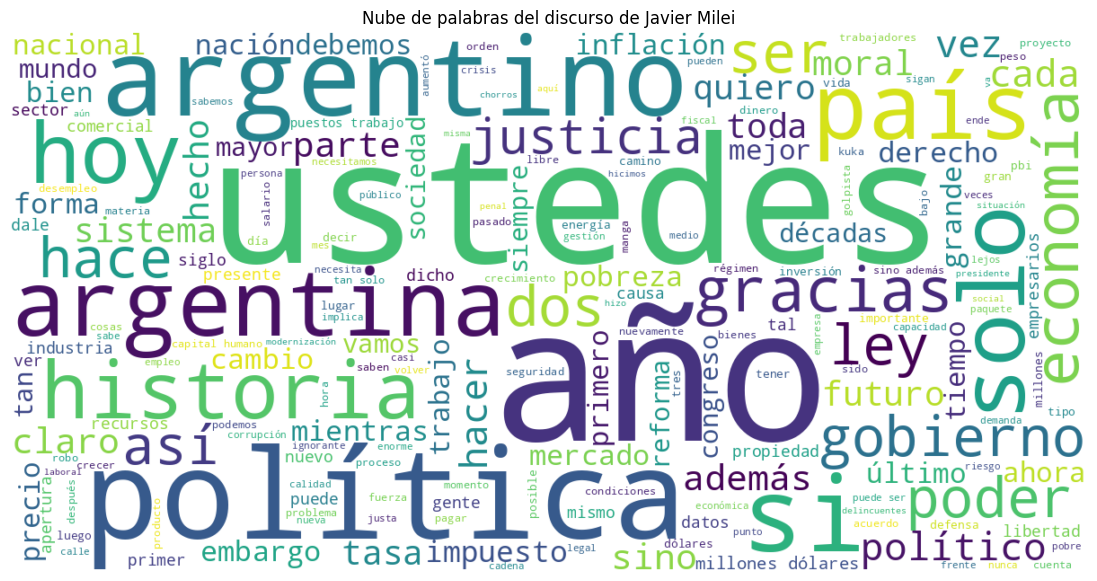

In [ ]:
# Creamos la nube de palabras
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(texto_filtrado)

# Mostramos la nube
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras del discurso de Javier Milei")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


En este punto se tomó el discurso extraído previamente y se lo descompuso en oraciones. Luego, cada oración fue preprocesada de manera individual: se pasó a minúsculas, se eliminaron signos de puntuación, espacios innecesarios y stopwords, conservando únicamente las palabras alfabéticas relevantes. Finalmente, se construyó una matriz documento-vocabulario, considerando cada oración como un documento y cada palabra distinta como parte del vocabulario. Esta matriz permite representar numéricamente la presencia de palabras en cada oración del texto.

# Código para limpiar, preprocesar y separar en oraciones

In [ ]:
# Descomponemos el texto en oraciones
oraciones = sent_tokenize(texto_completo, language="spanish")

print("Cantidad de oraciones:", len(oraciones))
print("\nPrimeras 3 oraciones:\n")
for o in oraciones[:3]:
    print(o)
    print()

# Limpiamos y preprocesamos cada oración
stop_words = set(stopwords.words("spanish"))

oraciones_limpias = []

for oracion in oraciones:
    # Pasamos a minúsculas
    oracion = oracion.lower()

    # Eliminamos signos de puntuación
    oracion = oracion.translate(str.maketrans('', '', string.punctuation))

    # Eliminamos espacios repetidos
    oracion = re.sub(r"\s+", " ", oracion).strip()

    # Tokenizamos la oración
    tokens_oracion = word_tokenize(oracion, language="spanish")

    # Quitamos stopwords y tokens que no sean alfabéticos
    tokens_filtrados = [
        token for token in tokens_oracion
        if token.isalpha() and token not in stop_words
    ]

    # Volvemos a unir la oración ya limpia
    oracion_limpia = " ".join(tokens_filtrados)

    # Guardamos solo las oraciones que no queden vacías
    if oracion_limpia:
        oraciones_limpias.append(oracion_limpia)

print("Cantidad de oraciones limpias:", len(oraciones_limpias))
print("\nPrimeras 3 oraciones limpias:\n")
for o in oraciones_limpias[:3]:
    print(o)
    print()

Cantidad de oraciones: 496

Primeras 3 oraciones:

Diputados y senadores del Congreso de la Nación, gobernadores, ministros de la Corte Suprema de Justicia, embajadores, estimados miembros del Gabinete nacional, y a todos los argentinos que nos están escuchando desde su hogar, buenas noches.

Además, quiero hacer un saludo muy especial porque hoy, en esta casa, nos honra el máximo representante de la historia del liberalismo argentino, el Doctor Alberto Benegas Lynch (h).

Gracias, profe, gracias.

Cantidad de oraciones limpias: 495

Primeras 3 oraciones limpias:

diputados senadores congreso nación gobernadores ministros corte suprema justicia embajadores estimados miembros gabinete nacional argentinos escuchando hogar buenas noches

además quiero hacer saludo especial hoy casa honra máximo representante historia liberalismo argentino doctor alberto benegas lynch h

gracias profe gracias



# Código para armar la matriz documento-vocabulario

In [ ]:
# Creamos el vectorizador
vectorizer = CountVectorizer()

# Ajustamos el modelo a las oraciones limpias y transformamos
X = vectorizer.fit_transform(oraciones_limpias)

# Convertimos la matriz en un DataFrame para verla mejor
matriz_doc_vocab = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print("Dimensión de la matriz:", matriz_doc_vocab.shape)
matriz_doc_vocab.head()

Dimensión de la matriz: (495, 2433)


,abastecer,abocado,abordar,abra,abrazar,abre,abrir,absoluta,absurdos,abundancia,...,éste,ética,éxito,órdenes,últimas,último,últimos,única,únicas,único
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



#### 2.3.2 Determina la longitud de tu vocabulario.

La longitud del vocabulario se obtuvo a partir de la matriz documento-vocabulario construida en el punto anterior. En este caso, el vocabulario está formado por todas las palabras distintas que aparecen en las oraciones preprocesadas del discurso. Por lo tanto, su longitud corresponde a la cantidad total de términos únicos presentes en el texto luego de la limpieza.

In [ ]:
# Obtenemos el vocabulario
vocabulario = vectorizer.get_feature_names_out()

# Calculamos su longitud
longitud_vocabulario = len(vocabulario)

print("Longitud del vocabulario:", longitud_vocabulario)
print(vocabulario[:50])

Longitud del vocabulario: 2433
['abastecer' 'abocado' 'abordar' 'abra' 'abrazar' 'abre' 'abrir'
 'absoluta' 'absurdos' 'abundancia' 'abundante' 'abusivamente' 'acabamos'
 'acaso' 'accede' 'acceder' 'acceso' 'accionar' 'acciones' 'acción'
 'aceleraba' 'acelerara' 'aceptar' 'acero' 'acierto' 'aclaro' 'acompañado'
 'acompañaron' 'acompañe' 'acoplamiento' 'acorde' 'activamente'
 'actividad' 'activo' 'activos' 'actor' 'actores' 'actos' 'actual'
 'actuales' 'actuar' 'acudió' 'acuerdo' 'acuerdos' 'acumula' 'acumulación'
 'acumular' 'acusatorio' 'acá' 'adam']



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

En este punto se aplicó la técnica TF-IDF sobre las oraciones preprocesadas del discurso. Para ello, cada oración fue considerada como un documento y se calculó el peso de cada término en función de su frecuencia dentro de la oración y de su importancia relativa en el conjunto total de oraciones. Esto permite resaltar las palabras que son más representativas en determinadas partes del discurso y no solo las más repetidas en general.

In [ ]:
# Creamos el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer()

# Ajustamos y transformamos las oraciones limpias
X_tfidf = tfidf_vectorizer.fit_transform(oraciones_limpias)

# Convertimos la matriz en DataFrame para verla mejor
matriz_tfidf = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("Dimensión de la matriz TF-IDF:", matriz_tfidf.shape)
matriz_tfidf.head()



Dimensión de la matriz TF-IDF: (495, 2433)


,abastecer,abocado,abordar,abra,abrazar,abre,abrir,absoluta,absurdos,abundancia,...,éste,ética,éxito,órdenes,últimas,último,últimos,única,únicas,único
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Calculamos el promedio de TF-IDF por palabra
promedio_tfidf = matriz_tfidf.mean(axis=0).sort_values(ascending=False)

print("Palabras con mayor peso TF-IDF:\n")
print(promedio_tfidf.head(20))

Palabras con mayor peso TF-IDF:

ustedes       0.018160
gracias       0.013937
solo          0.012965
si            0.012683
argentina     0.012571
política      0.011146
años          0.010964
argentinos    0.010869
dale          0.010653
hoy           0.010653
ser           0.010631
país          0.010596
dos           0.010504
año           0.009312
economía      0.009039
claro         0.008746
historia      0.008309
trabajo       0.008095
gobierno      0.008018
puede         0.007900
dtype: float64


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

Explicación del formato de la matriz resultante:

La matriz resultante tiene un tamaño de 495 × 2433. Las 495 filas representan los documentos, que en este caso son las oraciones del discurso, y las 2433 columnas representan el vocabulario, es decir, las palabras únicas obtenidas luego del preprocesamiento. Cada valor de la matriz TF-IDF indica la importancia de una palabra dentro de una oración.

Conclusiones:

Este proceso permitió transformar el discurso en una representación numérica para poder analizarlo computacionalmente. A partir de la segmentación en oraciones, la construcción del vocabulario y la aplicación de TF-IDF, fue posible identificar la relevancia de las palabras dentro del texto y organizar la información de una manera útil para el análisis de lenguaje natural.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

En este trabajo práctico se aplicaron técnicas de web scraping y preprocesamiento de texto sobre un discurso obtenido desde una página web oficial. A partir de la extracción del contenido, fue posible limpiarlo, segmentarlo en oraciones, identificar stopwords, generar una nube de palabras y construir una matriz documento-vocabulario. Luego, mediante TF-IDF, se logró representar el texto en forma numérica y analizar la relevancia de los términos dentro del discurso. En conclusión, el trabajo permitió ver de manera práctica cómo un texto real puede transformarse en datos estructurados para su análisis mediante herramientas de procesamiento de lenguaje natural.